In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
dataset = pd.read_csv('C:/Users/ADMIN/Desktop/FBS/Data Science/Data sets/Mall_Customers.csv')

In [35]:
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [36]:
dataset.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

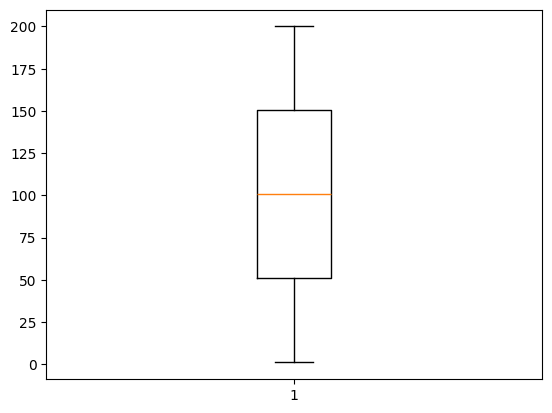

In [37]:
plt.boxplot(dataset['CustomerID'])
plt.show()

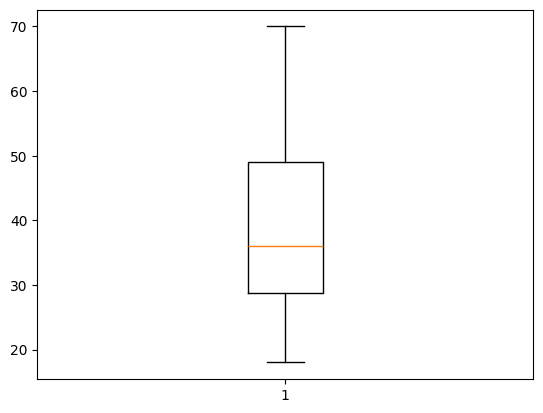

In [38]:
plt.boxplot(dataset['Age'])
plt.show()

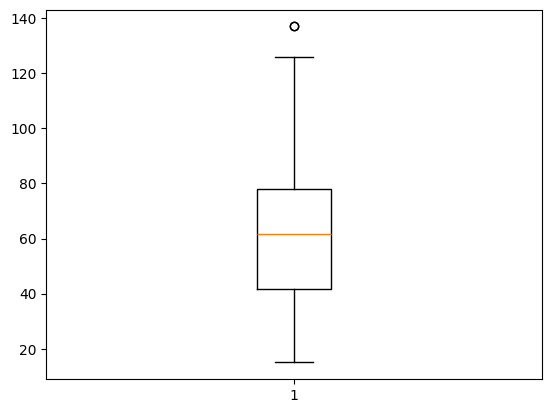

In [39]:
plt.boxplot(dataset['Annual Income (k$)'])
plt.show()

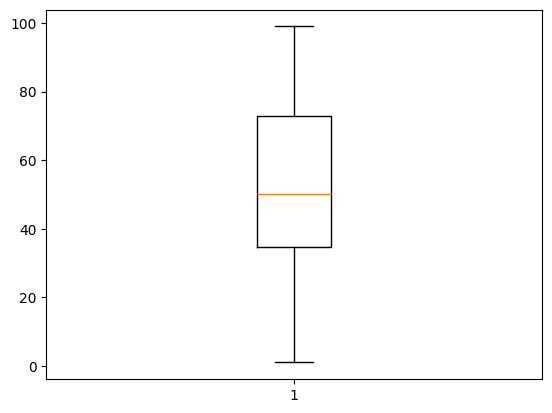

In [40]:
plt.boxplot(dataset['Spending Score (1-100)'])
plt.show()

<Axes: xlabel='CustomerID', ylabel='Count'>

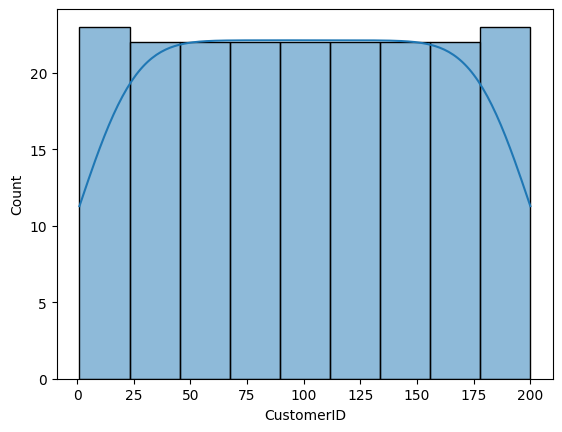

In [41]:
sns.histplot(dataset,x="CustomerID",kde = True)

<Axes: xlabel='Age', ylabel='Count'>

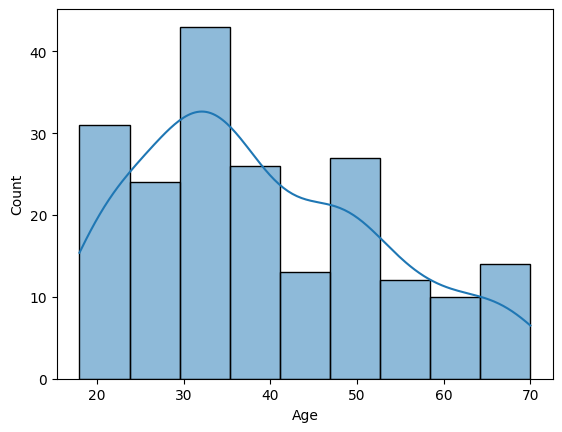

In [42]:
sns.histplot(dataset,x="Age",kde = True)

<Axes: xlabel='Annual Income (k$)', ylabel='Count'>

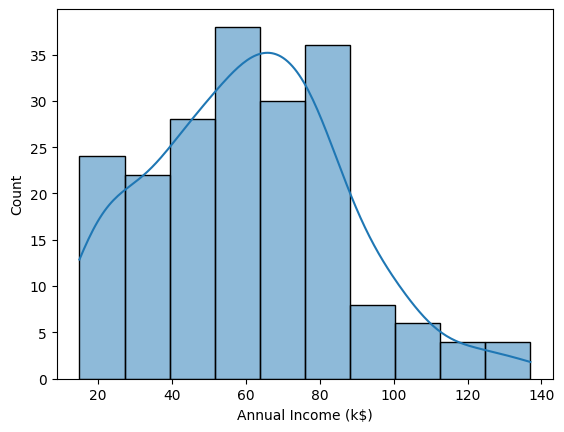

In [43]:
sns.histplot(dataset,x="Annual Income (k$)",kde = True)

<Axes: xlabel='Spending Score (1-100)', ylabel='Count'>

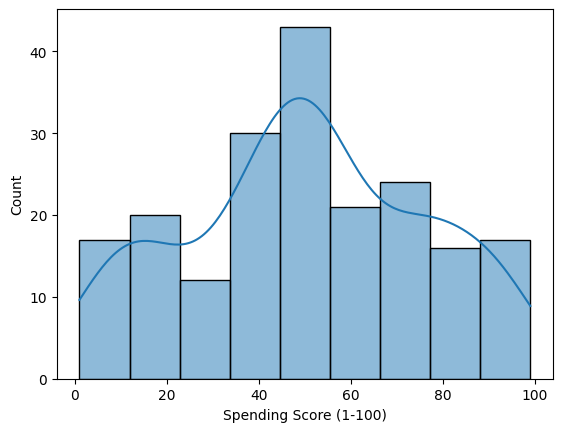

In [44]:
sns.histplot(dataset,x="Spending Score (1-100)",kde = True)

In [45]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dataset['Gender'] = le.fit_transform(dataset['Gender'])

In [46]:
X =dataset.iloc[:,1:]

In [47]:
X

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


In [48]:
from sklearn.cluster import KMeans


In [49]:
output=[]
k = []
for i in range(3, 11):
    km = KMeans(n_clusters=i)
    km.fit(X)
    k.append(i)
    # km.i
    output.append(km.inertia_)

In [50]:
k

[3, 4, 5, 6, 7, 8, 9, 10]

In [51]:
output

[169090.62656249997,
 135462.99361957703,
 102862.465849208,
 76396.41777073094,
 51460.304105434036,
 47513.363183806214,
 45665.82599206349,
 38648.40391601862]

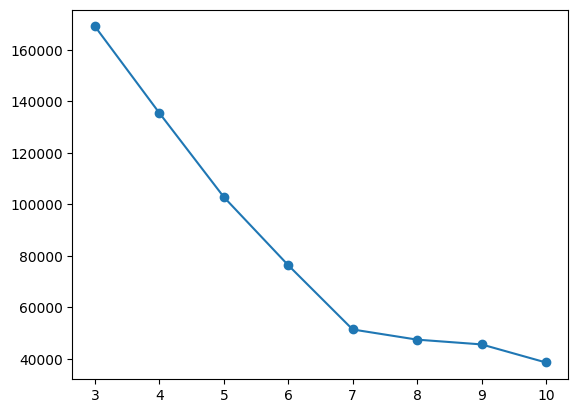

In [52]:
plt.plot(k,output,marker="o")

In [64]:
km = KMeans(n_clusters=5)
km.fit(X)
centriods = km.cluster_centers_


In [65]:
labels= km.labels_

In [66]:
labels

array([3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 4, 2, 1, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 1, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2], dtype=int32)

In [67]:
pd.concat([dataset,pd.DataFrame(labels,columns=["cluster"])],axis=1)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,1,19,15,39,3
1,2,1,21,15,81,0
2,3,0,20,16,6,3
3,4,0,23,16,77,0
4,5,0,31,17,40,3
...,...,...,...,...,...,...
195,196,0,35,120,79,2
196,197,0,45,126,28,4
197,198,1,32,126,74,2
198,199,1,32,137,18,4


NameError: name 'centroids' is not defined

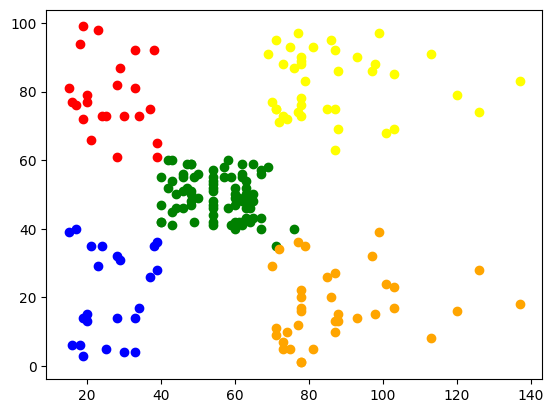

In [68]:
plt.scatter(dataset[labels==0]['Annual Income (k$)'],dataset[labels==0]['Spending Score (1-100)'],color="red")
plt.scatter(dataset[labels==1]['Annual Income (k$)'],dataset[labels==1]['Spending Score (1-100)'],color="green")
plt.scatter(dataset[labels==2]['Annual Income (k$)'],dataset[labels==2]['Spending Score (1-100)'],color="yellow")
plt.scatter(dataset[labels==3]['Annual Income (k$)'],dataset[labels==3]['Spending Score (1-100)'],color="blue")
plt.scatter(dataset[labels==4]['Annual Income (k$)'],dataset[labels==4]['Spending Score (1-100)'],color="orange")
plt.scatter(centriods[:,2], centroids[:,3],color="black")

In [ ]:
dataset[labels==0]

In [ ]:
from sklearn.metrics import silhouette_score


In [ ]:
silhouette_score(X,labels)